# 🧠 Artificial Neural Networks from Scratch
## A Complete, Intuitive Journey into Deep Learning

**Author's Note:** This notebook is designed to build your understanding from first principles. Every line of code, every equation, and every visualization serves your learning. Take your time with each section.

---

## Table of Contents
1. [Introduction & Motivation](#intro)
2. [Mathematical Foundations](#math)
3. [The Neuron: Building Block](#neuron)
4. [Activation Functions](#activation)
5. [Forward Propagation](#forward)
6. [Loss Functions](#loss)
7. [Backward Propagation](#backward)
8. [Complete Neural Network Implementation](#implementation)
9. [Training & Optimization](#training)
10. [Real-World Example](#example)
11. [Visualization & Analysis](#visualization)
12. [Advanced Topics & Extensions](#advanced)

In [1]:
# Essential imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("🎨 Environment Ready! Let's build intelligence from scratch.")

🎨 Environment Ready! Let's build intelligence from scratch.


<a id='intro'></a>
## 1. Introduction & Motivation

### Why Neural Networks?

Imagine teaching a computer to recognize patterns the way your brain does. That's the essence of neural networks. Unlike traditional programming where we explicitly code rules, neural networks **learn** rules from data.

### The Big Picture

```
Input Data → [Hidden Layers] → Output Prediction
     ↓              ↓                 ↓
  Features    Pattern Extraction   Decision
```

### What We'll Build

We're creating a fully functional neural network that can:
- Learn complex, non-linear patterns
- Adjust itself through experience (training)
- Make predictions on new data

**Key Insight:** Every concept builds on the previous one. Master each section before moving forward.

<a id='math'></a>
## 2. Mathematical Foundations

### 2.1 Linear Algebra Refresher

Neural networks are fundamentally matrix operations. Let's understand the key operations:

#### Matrix Multiplication
For matrices $A_{m \times n}$ and $B_{n \times p}$:

$$C_{m \times p} = A \cdot B$$

where $C_{ij} = \sum_{k=1}^{n} A_{ik} \cdot B_{kj}$

#### Element-wise Operations
$$A \odot B = \begin{bmatrix} a_{11} \cdot b_{11} & a_{12} \cdot b_{12} \\ a_{21} \cdot b_{21} & a_{22} \cdot b_{22} \end{bmatrix}$$

### 2.2 Calculus: The Gradient

The gradient tells us the direction of steepest ascent:

$$\nabla f(x) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \end{bmatrix}$$

**Why it matters:** We use gradients to find the direction that *decreases* our error (loss).

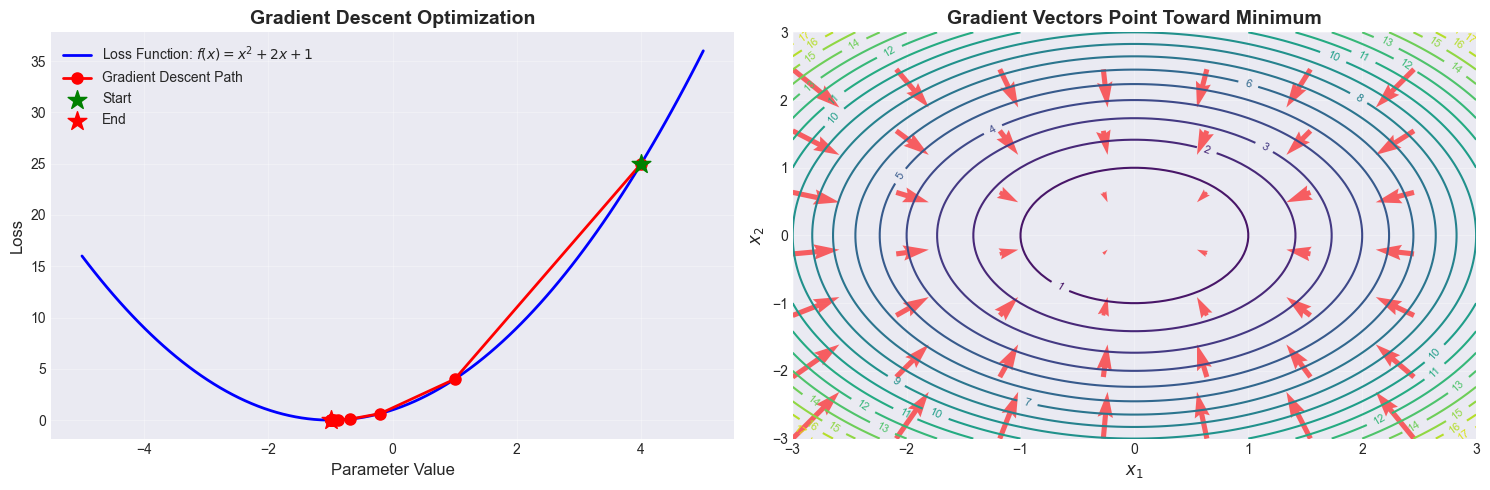

📊 Key Observations:
  • Started at x = 4.00
  • Converged to x = -1.00
  • Optimal point: x = -1.0 (where gradient = 0)
  • Red arrows show negative gradient direction (descent)


In [2]:
# Visualizing gradients and optimization
def plot_gradient_descent():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Create a simple quadratic function
    x = np.linspace(-5, 5, 100)
    y = x**2 + 2*x + 1
    
    # Gradient descent steps
    learning_rate = 0.3
    x_current = 4.0
    history = [x_current]
    
    for _ in range(10):
        gradient = 2*x_current + 2
        x_current = x_current - learning_rate * gradient
        history.append(x_current)
    
    # Plot 1: Function and gradient descent path
    ax1.plot(x, y, 'b-', linewidth=2, label='Loss Function: $f(x) = x^2 + 2x + 1$')
    ax1.plot(history, [h**2 + 2*h + 1 for h in history], 'ro-', 
             markersize=8, linewidth=2, label='Gradient Descent Path')
    ax1.scatter(history[0], history[0]**2 + 2*history[0] + 1, 
                color='green', s=200, zorder=5, label='Start', marker='*')
    ax1.scatter(history[-1], history[-1]**2 + 2*history[-1] + 1, 
                color='red', s=200, zorder=5, label='End', marker='*')
    ax1.set_xlabel('Parameter Value', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Gradient Descent Optimization', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: 2D contour plot
    x1 = np.linspace(-3, 3, 100)
    x2 = np.linspace(-3, 3, 100)
    X1, X2 = np.meshgrid(x1, x2)
    Z = X1**2 + X2**2
    
    contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
    ax2.clabel(contour, inline=True, fontsize=8)
    
    # Gradient vectors
    step = 15
    x1_arrows = X1[::step, ::step]
    x2_arrows = X2[::step, ::step]
    u = -2 * x1_arrows  # Negative gradient
    v = -2 * x2_arrows
    ax2.quiver(x1_arrows, x2_arrows, u, v, color='red', alpha=0.6)
    
    ax2.set_xlabel('$x_1$', fontsize=12)
    ax2.set_ylabel('$x_2$', fontsize=12)
    ax2.set_title('Gradient Vectors Point Toward Minimum', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Key Observations:")
    print(f"  • Started at x = {history[0]:.2f}")
    print(f"  • Converged to x = {history[-1]:.2f}")
    print(f"  • Optimal point: x = -1.0 (where gradient = 0)")
    print("  • Red arrows show negative gradient direction (descent)")

plot_gradient_descent()

<a id='neuron'></a>
## 3. The Neuron: Building Block of Intelligence

### 3.1 Biological Inspiration

Real neurons:
1. Receive signals through **dendrites**
2. Process in the **cell body**
3. Send output through **axon**

### 3.2 Artificial Neuron (Perceptron)

```
Inputs: x₁, x₂, ..., xₙ
   ↓     ↓         ↓
Weights: w₁, w₂, ..., wₙ
   ↓     ↓         ↓
Sum: z = Σ(wᵢ·xᵢ) + b
   ↓
Activation: a = σ(z)
   ↓
Output
```

### 3.3 Mathematical Formulation

For a single neuron:

$$z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

$$a = \sigma(z)$$

where:
- $\mathbf{x} = [x_1, x_2, ..., x_n]^T$ are inputs
- $\mathbf{w} = [w_1, w_2, ..., w_n]^T$ are weights
- $b$ is the bias
- $\sigma$ is the activation function

**Intuition:** 
- **Weights** determine importance of each input
- **Bias** shifts the decision boundary
- **Activation** introduces non-linearity

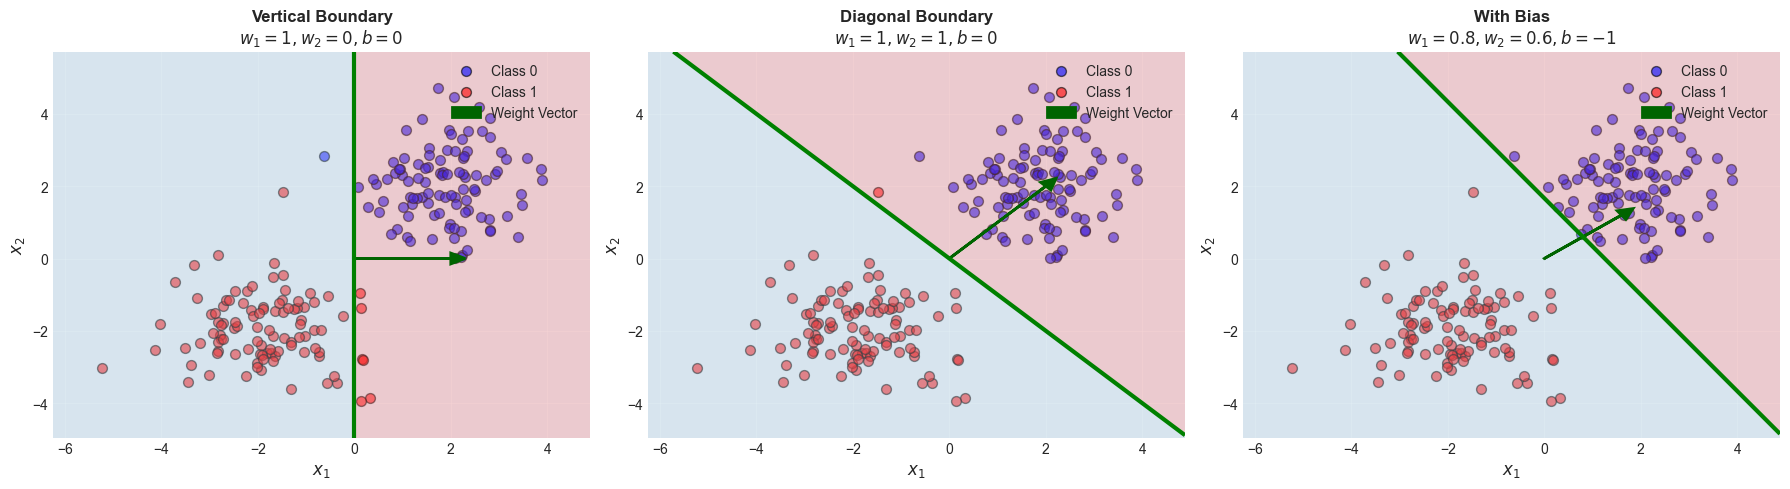


🧠 Understanding the Neuron:
  • Green line: Decision boundary (z = 0)
  • Green arrow: Weight vector (perpendicular to boundary)
  • Bias shifts the boundary away from origin
  • Blue region: Neuron outputs negative values
  • Red region: Neuron outputs positive values


In [3]:
# Implementing and visualizing a single neuron
class SingleNeuron:
    def __init__(self, n_inputs):
        self.weights = np.random.randn(n_inputs) * 0.1
        self.bias = np.random.randn() * 0.1
    
    def forward(self, x):
        """Forward pass through the neuron"""
        z = np.dot(self.weights, x) + self.bias
        return z

def visualize_neuron_decision_boundary():
    """Visualize how a neuron creates a decision boundary"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Generate 2D data
    np.random.seed(42)
    n_samples = 100
    X_class0 = np.random.randn(n_samples, 2) + np.array([2, 2])
    X_class1 = np.random.randn(n_samples, 2) + np.array([-2, -2])
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])
    
    # Three different neurons
    configs = [
        {'w': np.array([1, 0]), 'b': 0, 'title': 'Vertical Boundary\n$w_1=1, w_2=0, b=0$'},
        {'w': np.array([1, 1]), 'b': 0, 'title': 'Diagonal Boundary\n$w_1=1, w_2=1, b=0$'},
        {'w': np.array([0.8, 0.6]), 'b': -1, 'title': 'With Bias\n$w_1=0.8, w_2=0.6, b=-1$'}
    ]
    
    for idx, (ax, config) in enumerate(zip(axes, configs)):
        # Plot data points
        ax.scatter(X_class0[:, 0], X_class0[:, 1], c='blue', s=50, 
                  alpha=0.6, label='Class 0', edgecolors='k')
        ax.scatter(X_class1[:, 0], X_class1[:, 1], c='red', s=50, 
                  alpha=0.6, label='Class 1', edgecolors='k')
        
        # Create decision boundary
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                            np.linspace(y_min, y_max, 200))
        
        # Calculate z = w·x + b for all points
        Z = config['w'][0] * xx + config['w'][1] * yy + config['b']
        
        # Plot decision boundary (where z = 0)
        ax.contour(xx, yy, Z, levels=[0], colors='green', linewidths=3)
        
        # Color regions
        ax.contourf(xx, yy, Z, levels=[-100, 0, 100], 
                   colors=['lightblue', 'lightcoral'], alpha=0.3)
        
        # Draw weight vector
        ax.arrow(0, 0, config['w'][0]*2, config['w'][1]*2, 
                head_width=0.3, head_length=0.3, fc='darkgreen', ec='darkgreen',
                linewidth=2, label='Weight Vector')
        
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_title(config['title'], fontsize=12, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    print("\n🧠 Understanding the Neuron:")
    print("  • Green line: Decision boundary (z = 0)")
    print("  • Green arrow: Weight vector (perpendicular to boundary)")
    print("  • Bias shifts the boundary away from origin")
    print("  • Blue region: Neuron outputs negative values")
    print("  • Red region: Neuron outputs positive values")

visualize_neuron_decision_boundary()

<a id='activation'></a>
## 4. Activation Functions: Adding Non-Linearity

### Why Activation Functions?

Without activation functions, stacking layers would just create another linear function:
$$f(x) = W_2(W_1 x + b_1) + b_2 = W_2W_1 x + W_2b_1 + b_2 = Wx + b$$

**Activation functions introduce non-linearity**, allowing networks to learn complex patterns.

### 4.1 Common Activation Functions

#### Sigmoid
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

**Properties:**
- Output range: (0, 1)
- Smooth gradient
- **Issue:** Vanishing gradients for large |z|

#### Tanh (Hyperbolic Tangent)
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

$$\tanh'(z) = 1 - \tanh^2(z)$$

**Properties:**
- Output range: (-1, 1)
- Zero-centered (better than sigmoid)
- Still suffers from vanishing gradients

#### ReLU (Rectified Linear Unit)
$$\text{ReLU}(z) = \max(0, z)$$

$$\text{ReLU}'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**Properties:**
- Most popular in modern networks
- No vanishing gradient for z > 0
- Computationally efficient
- **Issue:** "Dying ReLU" when z ≤ 0

#### Leaky ReLU
$$\text{LeakyReLU}(z) = \max(\alpha z, z), \quad \alpha = 0.01$$

**Properties:**
- Fixes dying ReLU problem
- Small gradient when z < 0

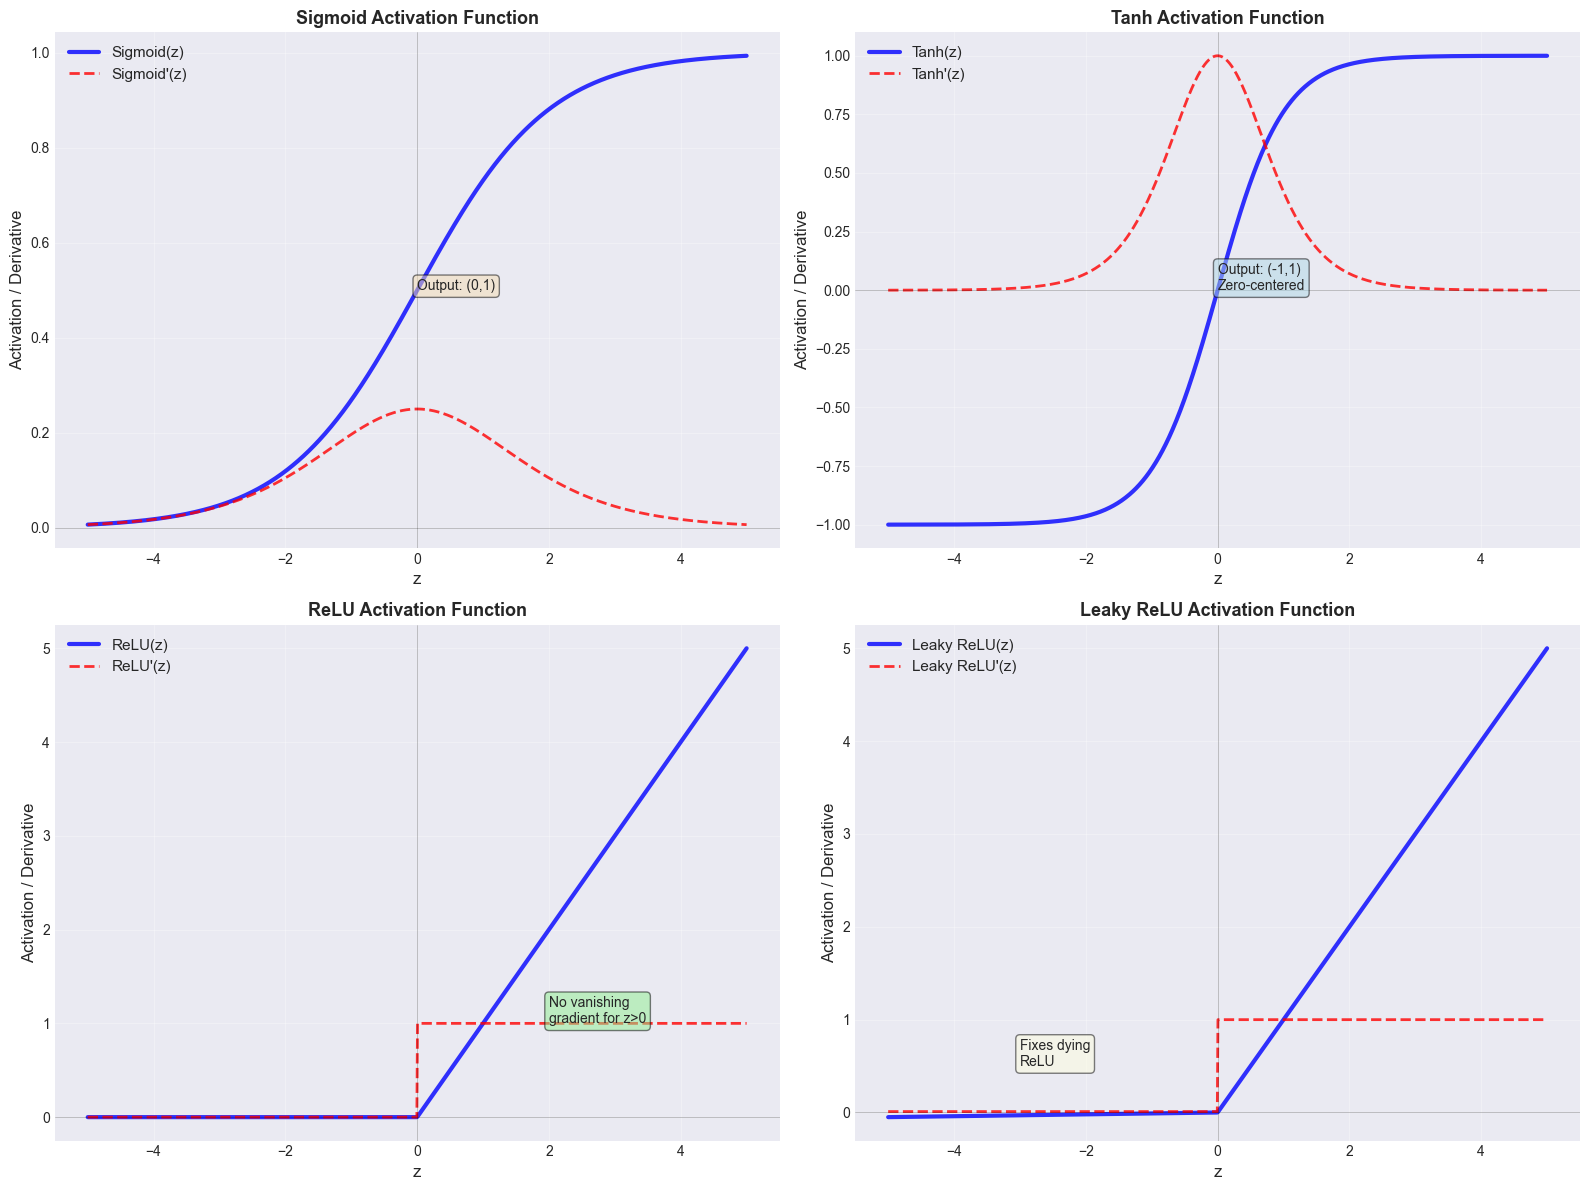


📈 Activation Function Comparison:

┌─────────────┬──────────────┬─────────────────┬───────────────────┐
│ Function    │ Output Range │ Pros            │ Cons              │
├─────────────┼──────────────┼─────────────────┼───────────────────┤
│ Sigmoid     │ (0, 1)       │ Smooth, bound   │ Vanishing grad    │
│ Tanh        │ (-1, 1)      │ Zero-centered   │ Vanishing grad    │
│ ReLU        │ [0, ∞)       │ Fast, no vanish │ Dying neurons     │
│ Leaky ReLU  │ (-∞, ∞)      │ Fixes dying     │ Not always better │
└─────────────┴──────────────┴─────────────────┴───────────────────┘


In [4]:
# Implementing activation functions
class ActivationFunctions:
    @staticmethod
    def sigmoid(z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip for numerical stability
    
    @staticmethod
    def sigmoid_derivative(z):
        """Derivative of sigmoid"""
        s = ActivationFunctions.sigmoid(z)
        return s * (1 - s)
    
    @staticmethod
    def tanh(z):
        """Tanh activation function"""
        return np.tanh(z)
    
    @staticmethod
    def tanh_derivative(z):
        """Derivative of tanh"""
        return 1 - np.tanh(z)**2
    
    @staticmethod
    def relu(z):
        """ReLU activation function"""
        return np.maximum(0, z)
    
    @staticmethod
    def relu_derivative(z):
        """Derivative of ReLU"""
        return (z > 0).astype(float)
    
    @staticmethod
    def leaky_relu(z, alpha=0.01):
        """Leaky ReLU activation function"""
        return np.where(z > 0, z, alpha * z)
    
    @staticmethod
    def leaky_relu_derivative(z, alpha=0.01):
        """Derivative of Leaky ReLU"""
        return np.where(z > 0, 1, alpha)

# Visualize activation functions
def plot_activation_functions():
    z = np.linspace(-5, 5, 1000)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    activations = [
        ('Sigmoid', ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
        ('Tanh', ActivationFunctions.tanh, ActivationFunctions.tanh_derivative),
        ('ReLU', ActivationFunctions.relu, ActivationFunctions.relu_derivative),
        ('Leaky ReLU', ActivationFunctions.leaky_relu, ActivationFunctions.leaky_relu_derivative)
    ]
    
    for idx, (name, func, deriv) in enumerate(activations):
        ax = axes[idx // 2, idx % 2]
        
        # Plot function
        y = func(z)
        dy = deriv(z)
        
        ax.plot(z, y, 'b-', linewidth=3, label=f'{name}(z)', alpha=0.8)
        ax.plot(z, dy, 'r--', linewidth=2, label=f"{name}'(z)", alpha=0.8)
        
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=11, loc='upper left')
        ax.set_xlabel('z', fontsize=12)
        ax.set_ylabel('Activation / Derivative', fontsize=12)
        ax.set_title(f'{name} Activation Function', fontsize=13, fontweight='bold')
        
        # Add annotations for key properties
        if name == 'Sigmoid':
            ax.text(0, 0.5, 'Output: (0,1)', fontsize=10, 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        elif name == 'Tanh':
            ax.text(0, 0, 'Output: (-1,1)\nZero-centered', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        elif name == 'ReLU':
            ax.text(2, 1, 'No vanishing\ngradient for z>0', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        else:
            ax.text(-3, 0.5, 'Fixes dying\nReLU', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Activation Function Comparison:")
    print("\n┌─────────────┬──────────────┬─────────────────┬───────────────────┐")
    print("│ Function    │ Output Range │ Pros            │ Cons              │")
    print("├─────────────┼──────────────┼─────────────────┼───────────────────┤")
    print("│ Sigmoid     │ (0, 1)       │ Smooth, bound   │ Vanishing grad    │")
    print("│ Tanh        │ (-1, 1)      │ Zero-centered   │ Vanishing grad    │")
    print("│ ReLU        │ [0, ∞)       │ Fast, no vanish │ Dying neurons     │")
    print("│ Leaky ReLU  │ (-∞, ∞)      │ Fixes dying     │ Not always better │")
    print("└─────────────┴──────────────┴─────────────────┴───────────────────┘")

plot_activation_functions()

<a id='forward'></a>
## 5. Forward Propagation: Data Flows Forward

### The Forward Pass

Forward propagation is the process of computing the output of the network given an input.

### For a Multi-Layer Network:

```
Input Layer → Hidden Layer 1 → Hidden Layer 2 → Output Layer
    X      →       h1        →       h2        →      ŷ
```

### Mathematical Formulation:

**Layer 1 (Input → Hidden):**
$$Z^{[1]} = W^{[1]}X + b^{[1]}$$
$$A^{[1]} = \sigma(Z^{[1]})$$

**Layer 2 (Hidden → Hidden):**
$$Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}$$
$$A^{[2]} = \sigma(Z^{[2]})$$

**Layer L (Hidden → Output):**
$$Z^{[L]} = W^{[L]}A^{[L-1]} + b^{[L]}$$
$$\hat{y} = \sigma(Z^{[L]})$$

### Dimensions:

For batch processing:
- $X \in \mathbb{R}^{n_{features} \times m}$ (m examples)
- $W^{[l]} \in \mathbb{R}^{n^{[l]} \times n^{[l-1]}}$
- $b^{[l]} \in \mathbb{R}^{n^{[l]} \times 1}$
- $A^{[l]} \in \mathbb{R}^{n^{[l]} \times m}$

where $n^{[l]}$ is the number of neurons in layer $l$.

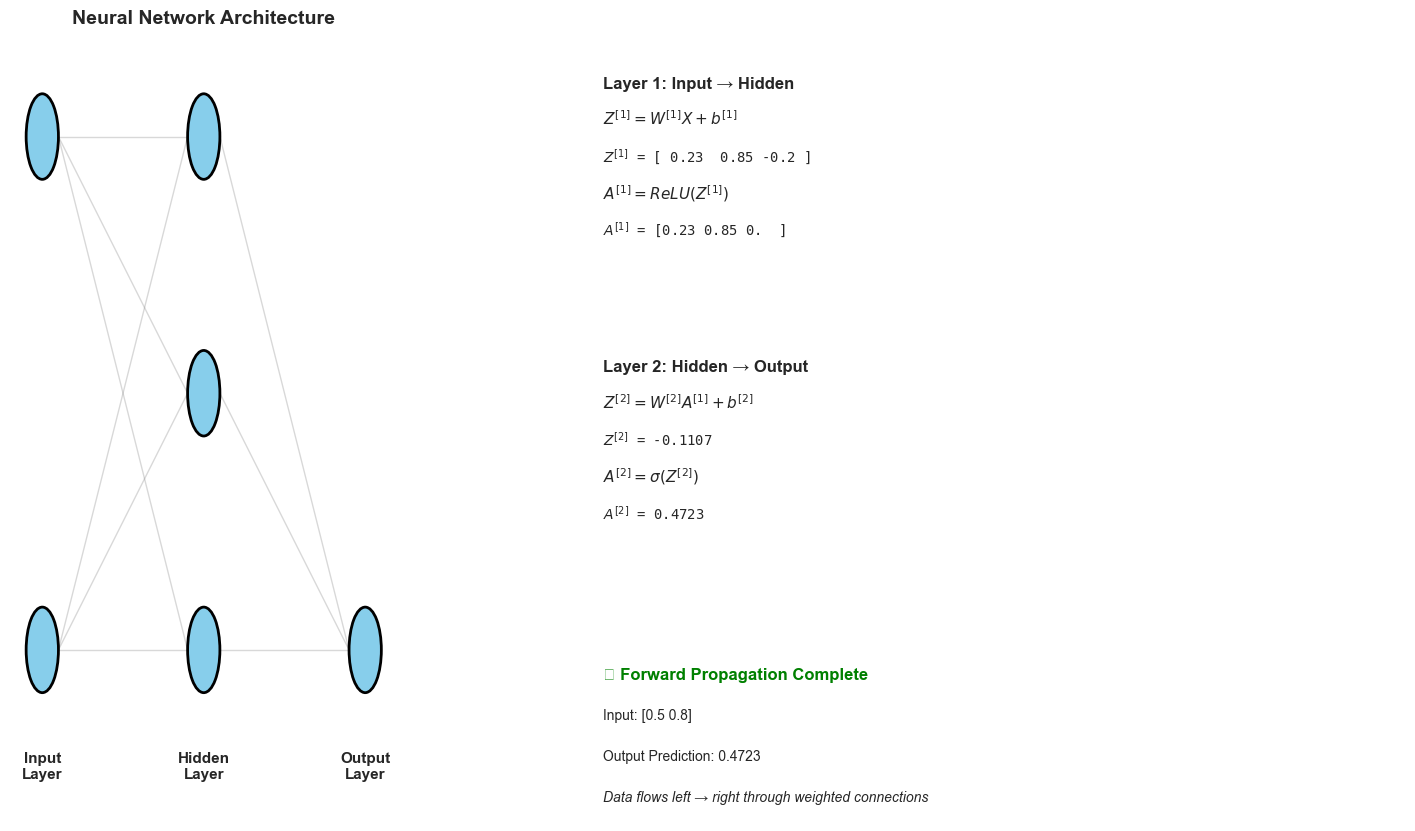


🔄 Forward Propagation Summary:
  1. Input: [0.5 0.8]
  2. Hidden layer output (after ReLU): [0.23 0.85 0.  ]
  3. Final prediction (after Sigmoid): 0.4723

  Each layer transforms the data through:
    • Linear transformation (W·x + b)
    • Non-linear activation function


In [5]:
# Visualizing forward propagation
def visualize_forward_propagation():
    """Create a detailed visualization of forward propagation"""
    
    # Create sample data
    np.random.seed(42)
    X = np.array([[0.5], [0.8]])  # 2 features, 1 example
    W1 = np.random.randn(3, 2) * 0.5  # 2 inputs → 3 hidden neurons
    b1 = np.random.randn(3, 1) * 0.1
    W2 = np.random.randn(1, 3) * 0.5  # 3 hidden → 1 output
    b2 = np.random.randn(1, 1) * 0.1
    
    # Forward pass
    Z1 = np.dot(W1, X) + b1
    A1 = ActivationFunctions.relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = ActivationFunctions.sigmoid(Z2)
    
    # Plotting
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)
    
    # Main network diagram
    ax_main = fig.add_subplot(gs[:, 0])
    
    # Layer positions
    layer_x = [0, 0.5, 1]
    layer_sizes = [2, 3, 1]
    
    # Draw network
    for i, (x_pos, size) in enumerate(zip(layer_x, layer_sizes)):
        y_positions = np.linspace(0.2, 0.8, size)
        for y_pos in y_positions:
            circle = plt.Circle((x_pos, y_pos), 0.05, color='skyblue', 
                               ec='black', linewidth=2, zorder=5)
            ax_main.add_patch(circle)
            
            # Add values
            if i == 0:  # Input layer
                val = X[int((y_pos - 0.2) / 0.6 * (len(X) - 1))][0]
                ax_main.text(x_pos, y_pos, f'{val:.2f}', ha='center', 
                           va='center', fontsize=10, fontweight='bold')
            elif i == 1:  # Hidden layer
                val = A1[int((y_pos - 0.2) / 0.6 * (size - 1))][0]
                ax_main.text(x_pos, y_pos, f'{val:.2f}', ha='center', 
                           va='center', fontsize=10, fontweight='bold')
            else:  # Output layer
                ax_main.text(x_pos, y_pos, f'{A2[0][0]:.2f}', ha='center', 
                           va='center', fontsize=10, fontweight='bold')
    
    # Draw connections
    for i in range(len(layer_x) - 1):
        size_current = layer_sizes[i]
        size_next = layer_sizes[i + 1]
        y_current = np.linspace(0.2, 0.8, size_current)
        y_next = np.linspace(0.2, 0.8, size_next)
        
        for y1 in y_current:
            for y2 in y_next:
                ax_main.plot([layer_x[i] + 0.05, layer_x[i + 1] - 0.05], 
                           [y1, y2], 'gray', alpha=0.3, linewidth=1)
    
    # Labels
    ax_main.text(0, 0.05, 'Input\nLayer', ha='center', fontsize=11, fontweight='bold')
    ax_main.text(0.5, 0.05, 'Hidden\nLayer', ha='center', fontsize=11, fontweight='bold')
    ax_main.text(1, 0.05, 'Output\nLayer', ha='center', fontsize=11, fontweight='bold')
    
    ax_main.set_xlim(-0.1, 1.1)
    ax_main.set_ylim(0, 0.9)
    ax_main.axis('off')
    ax_main.set_title('Neural Network Architecture', fontsize=14, fontweight='bold', pad=20)
    
    # Layer 1 computation details
    ax1 = fig.add_subplot(gs[0, 1:])
    ax1.text(0.1, 0.8, 'Layer 1: Input → Hidden', fontsize=12, fontweight='bold')
    ax1.text(0.1, 0.6, f'$Z^{{[1]}} = W^{{[1]}}X + b^{{[1]}}$', fontsize=11)
    ax1.text(0.1, 0.4, f'$Z^{{[1]}}$ = {np.round(Z1.flatten(), 2)}', fontsize=10, family='monospace')
    ax1.text(0.1, 0.2, f'$A^{{[1]}} = ReLU(Z^{{[1]}})$', fontsize=11)
    ax1.text(0.1, 0.0, f'$A^{{[1]}}$ = {np.round(A1.flatten(), 2)}', fontsize=10, family='monospace')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(-0.1, 1)
    ax1.axis('off')
    
    # Layer 2 computation details
    ax2 = fig.add_subplot(gs[1, 1:])
    ax2.text(0.1, 0.8, 'Layer 2: Hidden → Output', fontsize=12, fontweight='bold')
    ax2.text(0.1, 0.6, f'$Z^{{[2]}} = W^{{[2]}}A^{{[1]}} + b^{{[2]}}$', fontsize=11)
    ax2.text(0.1, 0.4, f'$Z^{{[2]}}$ = {Z2[0][0]:.4f}', fontsize=10, family='monospace')
    ax2.text(0.1, 0.2, f'$A^{{[2]}} = \\sigma(Z^{{[2]}})$', fontsize=11)
    ax2.text(0.1, 0.0, f'$A^{{[2]}}$ = {A2[0][0]:.4f}', fontsize=10, family='monospace')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(-0.1, 1)
    ax2.axis('off')
    
    # Summary
    ax3 = fig.add_subplot(gs[2, 1:])
    ax3.text(0.1, 0.7, '✓ Forward Propagation Complete', fontsize=12, fontweight='bold', color='green')
    ax3.text(0.1, 0.5, f'Input: {X.flatten()}', fontsize=10)
    ax3.text(0.1, 0.3, f'Output Prediction: {A2[0][0]:.4f}', fontsize=10)
    ax3.text(0.1, 0.1, 'Data flows left → right through weighted connections', fontsize=10, style='italic')
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔄 Forward Propagation Summary:")
    print(f"  1. Input: {X.flatten()}")
    print(f"  2. Hidden layer output (after ReLU): {np.round(A1.flatten(), 2)}")
    print(f"  3. Final prediction (after Sigmoid): {A2[0][0]:.4f}")
    print("\n  Each layer transforms the data through:")
    print("    • Linear transformation (W·x + b)")
    print("    • Non-linear activation function")

visualize_forward_propagation()

<a id='loss'></a>
## 6. Loss Functions: Measuring Error

### What is a Loss Function?

A loss function $\mathcal{L}$ measures how far our predictions $\hat{y}$ are from the true labels $y$. The goal of training is to **minimize this loss**.

### Common Loss Functions

#### 6.1 Mean Squared Error (MSE) - Regression
$$\mathcal{L}_{MSE} = \frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2$$

**When to use:** Regression problems

**Derivative:**
$$\frac{\partial \mathcal{L}_{MSE}}{\partial \hat{y}} = \frac{2}{m}(\hat{y} - y)$$

#### 6.2 Binary Cross-Entropy - Binary Classification
$$\mathcal{L}_{BCE} = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

**When to use:** Binary classification (0 or 1)

**Derivative:**
$$\frac{\partial \mathcal{L}_{BCE}}{\partial \hat{y}} = -\frac{1}{m}\left(\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}}\right)$$

#### 6.3 Categorical Cross-Entropy - Multi-class Classification
$$\mathcal{L}_{CCE} = -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{C}y_j^{(i)}\log(\hat{y}_j^{(i)})$$

where $C$ is the number of classes.

### Intuition

- **MSE:** Penalizes large errors more (squared term)
- **Cross-Entropy:** Heavily penalizes confident wrong predictions
- Lower loss = Better model performance

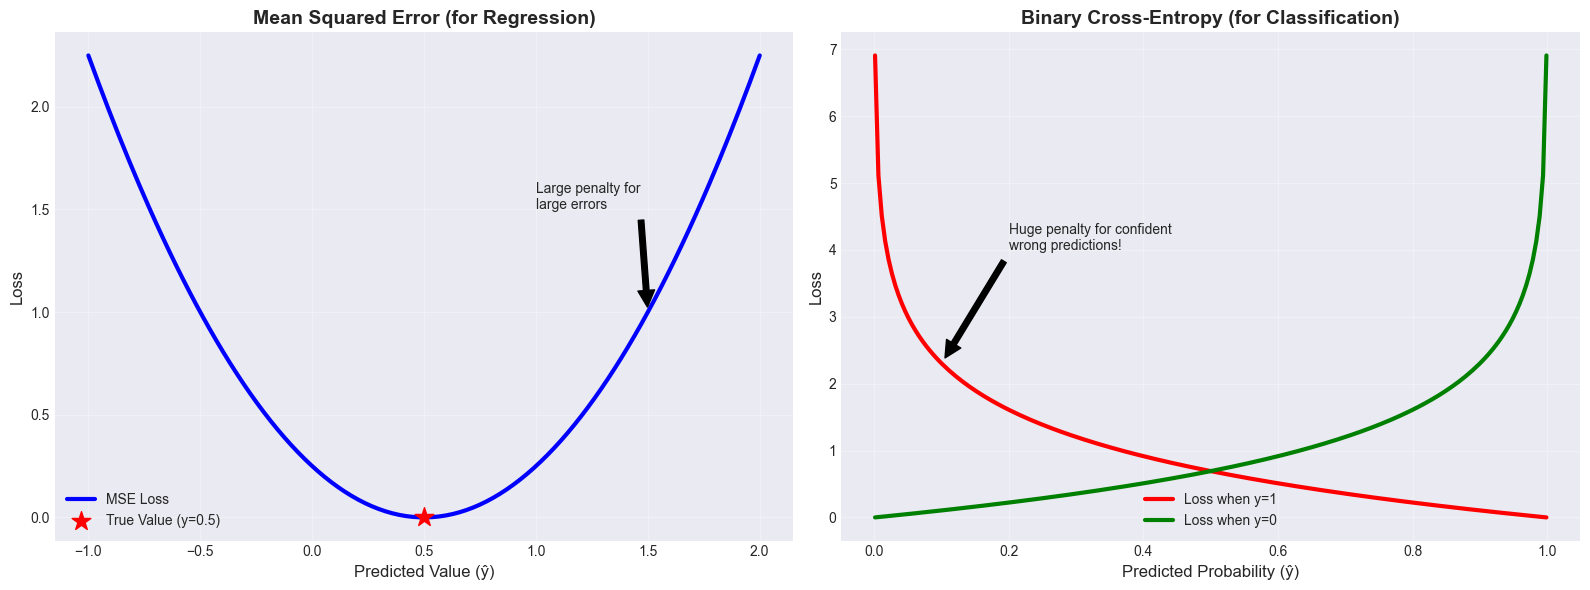


📉 Loss Function Insights:
  • MSE: Symmetric, quadratic penalty. Good for regression where errors have equal weight.
  • BCE: Asymmetric. Gives massive penalties for being very confident about the wrong class.
  • The choice of loss function is critical and depends on the problem type.


In [6]:
# Implementing loss functions
class LossFunctions:
    @staticmethod
    def mse(y_true, y_pred):
        """Mean Squared Error"""
        return np.mean((y_true - y_pred) ** 2)
    
    @staticmethod
    def mse_derivative(y_true, y_pred):
        """Derivative of MSE"""
        return 2 * (y_pred - y_true) / y_true.size
    
    @staticmethod
    def binary_cross_entropy(y_true, y_pred):
        """Binary Cross-Entropy Loss"""
        # Clip predictions to prevent log(0)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    @staticmethod
    def binary_cross_entropy_derivative(y_true, y_pred):
        """Derivative of Binary Cross-Entropy"""
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -(y_true / y_pred - (1 - y_true) / (1 - y_pred)) / y_true.size

# Visualize loss functions
def visualize_loss_functions():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Mean Squared Error (MSE)
    y_pred = np.linspace(-1, 2, 200)
    y_true = 0.5
    loss_mse = (y_true - y_pred)**2
    
    ax1.plot(y_pred, loss_mse, 'b-', linewidth=3, label='MSE Loss')
    ax1.scatter(y_true, 0, color='red', s=200, marker='*', zorder=5, label='True Value (y=0.5)')
    ax1.set_xlabel('Predicted Value (ŷ)', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Mean Squared Error (for Regression)', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.annotate('Large penalty for\nlarge errors', xy=(1.5, (0.5-1.5)**2), xytext=(1, 1.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
    
    # 2. Binary Cross-Entropy (BCE)
    y_pred_bce = np.linspace(0.001, 0.999, 200)
    
    # Case 1: True label = 1
    loss_bce_1 = -np.log(y_pred_bce)
    ax2.plot(y_pred_bce, loss_bce_1, 'r-', linewidth=3, label='Loss when y=1')
    
    # Case 2: True label = 0
    loss_bce_0 = -np.log(1 - y_pred_bce)
    ax2.plot(y_pred_bce, loss_bce_0, 'g-', linewidth=3, label='Loss when y=0')
    
    ax2.set_xlabel('Predicted Probability (ŷ)', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Binary Cross-Entropy (for Classification)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.annotate('Huge penalty for confident\nwrong predictions!', xy=(0.1, -np.log(0.1)), 
                 xytext=(0.2, 4), arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
    
    plt.tight_layout()
    plt.show()

    print("\n📉 Loss Function Insights:")
    print("  • MSE: Symmetric, quadratic penalty. Good for regression where errors have equal weight.")
    print("  • BCE: Asymmetric. Gives massive penalties for being very confident about the wrong class.")
    print("  • The choice of loss function is critical and depends on the problem type.")

visualize_loss_functions()

<a id='backward'></a>
## 7. Backward Propagation: The Magic of Learning

### What is Backpropagation?

Backpropagation is the algorithm that enables neural networks to learn. It computes gradients of the loss with respect to all parameters by applying the **chain rule** of calculus.

### The Chain Rule

If $y = f(g(x))$, then:
$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$

### Computational Graph

```
Forward Pass (Left → Right):
X → Z¹ → A¹ → Z² → A² → Loss

Backward Pass (Right → Left):
dL/dW¹, dL/db¹ ← dZ¹ ← dA¹ ← dZ² ← dA² ← dLoss/dA²
```

### Mathematical Derivation

#### Output Layer Gradient

For the last layer $L$:
$$dZ^{[L]} = \frac{\partial \mathcal{L}}{\partial Z^{[L]}} = \frac{\partial \mathcal{L}}{\partial A^{[L]}} \cdot \frac{\partial A^{[L]}}{\partial Z^{[L]}}$$

For binary cross-entropy with a sigmoid output, this simplifies beautifully:
$$dZ^{[L]} = A^{[L]} - Y$$

#### Hidden Layer Gradients

For layer $l$:
$$dZ^{[l]} = \frac{\partial \mathcal{L}}{\partial Z^{[l]}} = (W^{[l+1]T} dZ^{[l+1]}) \odot g'^{[l]}(Z^{[l]})$$

where $\odot$ is element-wise multiplication and $g'$ is the activation derivative.

#### Parameter Gradients

$$dW^{[l]} = \frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{1}{m} dZ^{[l]} \cdot A^{[l-1]T}$$

$$db^{[l]} = \frac{\partial \mathcal{L}}{\partial b^{[l]}} = \frac{1}{m}\sum_{i=1}^{m}dZ^{[l](i)}$$

### Dimensions Check (Critical!)

For layer $l$ with $n^{[l]}$ neurons:
- $dW^{[l]}$: Same shape as $W^{[l]}$ → $(n^{[l]}, n^{[l-1]})$
- $db^{[l]}$: Same shape as $b^{[l]}$ → $(n^{[l]}, 1)$
- $dZ^{[l]}$: Same shape as $Z^{[l]}$ → $(n^{[l]}, m)$
- $dA^{[l]}$: Same shape as $A^{[l]}$ → $(n^{[l]}, m)$

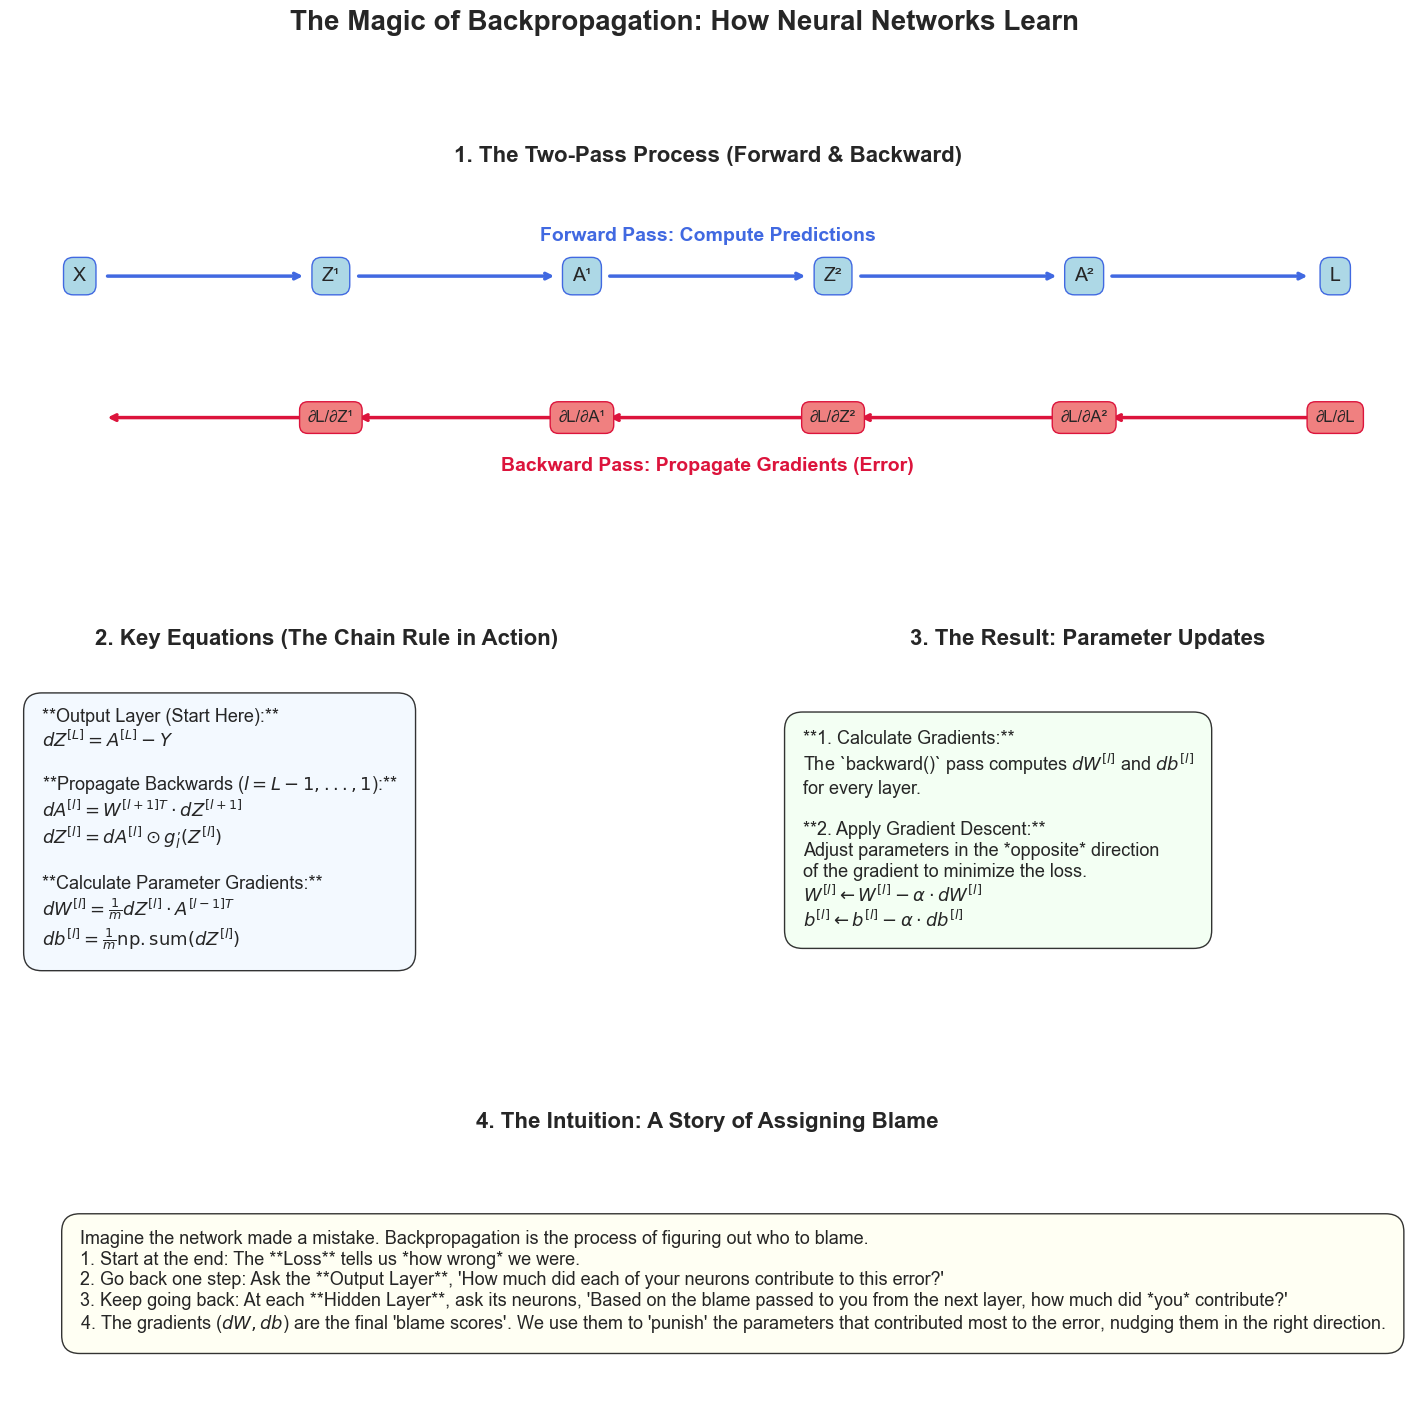

In [7]:
# Detailed backpropagation visualization
def visualize_backpropagation():
    """A refined and comprehensive visualization of the backpropagation algorithm."""

    fig = plt.figure(figsize=(18, 16))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 2, 1.5], hspace=0.4)
    fig.suptitle('The Magic of Backpropagation: How Neural Networks Learn', fontsize=20, fontweight='bold')

    # --- Part 1: The Computational Graph ---
    ax1 = fig.add_subplot(gs[0])
    ax1.set_title('1. The Two-Pass Process (Forward & Backward)', fontsize=16, fontweight='bold')
    nodes = {'X': 'Input', 'Z¹': 'Linear ¹', 'A¹': 'Activation ¹', 'Z²': 'Linear ²', 'A²': 'Activation ²', 'L': 'Loss'}
    x_pos = np.linspace(0.05, 0.95, len(nodes))
    node_keys = list(nodes.keys())

    # Draw forward pass
    for i in range(len(node_keys) - 1):
        ax1.annotate('', xy=(x_pos[i+1], 0.7), xytext=(x_pos[i], 0.7),
                     arrowprops=dict(arrowstyle='->', lw=2.5, color='royalblue', shrinkA=20, shrinkB=20))
    ax1.text(0.5, 0.8, 'Forward Pass: Compute Predictions', ha='center', fontsize=14, color='royalblue', fontweight='bold')

    # Draw backward pass
    for i in range(len(node_keys) - 1, 0, -1):
        ax1.annotate('', xy=(x_pos[i-1], 0.3), xytext=(x_pos[i], 0.3),
                     arrowprops=dict(arrowstyle='->', lw=2.5, color='crimson', shrinkA=20, shrinkB=20))
    ax1.text(0.5, 0.15, 'Backward Pass: Propagate Gradients (Error)', ha='center', fontsize=14, color='crimson', fontweight='bold')

    # Draw nodes
    for i, key in enumerate(node_keys):
        # Forward node
        ax1.text(x_pos[i], 0.7, key, ha='center', va='center', fontsize=14,
                 bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', ec='royalblue'))
        # Backward node (gradient)
        if key != 'X':
            grad_label = f'∂L/∂{key}'
            ax1.text(x_pos[i], 0.3, grad_label, ha='center', va='center', fontsize=12,
                     bbox=dict(boxstyle='round,pad=0.5', fc='lightcoral', ec='crimson'))
    ax1.axis('off')

    # --- Part 2: Core Mechanics (Equations & Flow) ---
    sub_gs = gs[1].subgridspec(1, 2, wspace=0.2)
    ax2 = fig.add_subplot(sub_gs[0])
    ax3 = fig.add_subplot(sub_gs[1])

    # Key Equations
    ax2.set_title('2. Key Equations (The Chain Rule in Action)', fontsize=16, fontweight='bold')
    eq_text = (
        r'**Output Layer (Start Here):**' + '\n' +
        r'$dZ^{[L]} = A^{[L]} - Y$' + '\n\n' +
        r'**Propagate Backwards ($l=L-1, ..., 1$):**' + '\n' +
        r'$dA^{[l]} = W^{[l+1]T} \cdot dZ^{[l+1]}$' + '\n' +
        r'$dZ^{[l]} = dA^{[l]} \odot g_l^{,}(Z^{[l]})$' + '\n\n' +
        r'**Calculate Parameter Gradients:**' + '\n' +
        r'$dW^{[l]} = \frac{1}{m} dZ^{[l]} \cdot A^{[l-1]T}$' + '\n' +
        r'$db^{[l]} = \frac{1}{m} \mathrm{np.sum}(dZ^{[l]})$'
    )
    ax2.text(0.05, 0.5, eq_text, fontsize=13, va='center',
             bbox=dict(boxstyle='round,pad=1', fc='aliceblue', alpha=0.8))
    ax2.axis('off')

    # Gradient Flow and Update
    ax3.set_title('3. The Result: Parameter Updates', fontsize=16, fontweight='bold')
    flow_text = (
        r'**1. Calculate Gradients:**' + '\n' +
        r'The `backward()` pass computes $dW^{[l]}$ and $db^{[l]}$' + '\n' +
        r'for every layer.' + '\n\n' +
        r'**2. Apply Gradient Descent:**' + '\n' +
        r'Adjust parameters in the *opposite* direction' + '\n' +
        r'of the gradient to minimize the loss.' + '\n' +
        r'$W^{[l]} \leftarrow W^{[l]} - \alpha \cdot dW^{[l]}$' + '\n' +
        r'$b^{[l]} \leftarrow b^{[l]} - \alpha \cdot db^{[l]}$'
    )
    ax3.text(0.05, 0.5, flow_text, fontsize=13, va='center',
             bbox=dict(boxstyle='round,pad=1', fc='honeydew', alpha=0.8))
    ax3.axis('off')

    # --- Part 3: The Intuition ---
    ax4 = fig.add_subplot(gs[2])
    ax4.set_title('4. The Intuition: A Story of Assigning Blame', fontsize=16, fontweight='bold')
    intuition_text = (
        "Imagine the network made a mistake. Backpropagation is the process of figuring out who to blame.\n"
        "1. Start at the end: The **Loss** tells us *how wrong* we were.\n"
        "2. Go back one step: Ask the **Output Layer**, 'How much did each of your neurons contribute to this error?'\n"
        "3. Keep going back: At each **Hidden Layer**, ask its neurons, 'Based on the blame passed to you from the next layer, "
        "how much did *you* contribute?'\n"
        "4. The gradients ($dW, db$) are the final 'blame scores'. We use them to 'punish' the parameters that contributed most to the error, "
        "nudging them in the right direction."
    )
    ax4.text(0.05, 0.45, intuition_text, fontsize=13, va='center', wrap=True,
             bbox=dict(boxstyle='round,pad=1', fc='ivory', alpha=0.8))
    ax4.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

visualize_backpropagation()

<a id='implementation'></a>
## 8. Complete Neural Network Implementation

Now we bring everything together into a complete, well-structured neural network class.

### Architecture Design

Our network will support:
- **Variable architecture**: Any number of hidden layers and neurons
- **Multiple activation functions**: ReLU, Sigmoid, Tanh
- **Batch processing**: Efficient matrix operations for faster training
- **Weight initialization**: He and Xavier initialization to prevent vanishing/exploding gradients
- **Regularization**: L2 regularization (weight decay) to combat overfitting
- **Training utilities**: Loss and accuracy tracking

### Class Structure

```python
class NeuralNetwork:
    ├── __init__()           # Initialize architecture, parameters, and hyperparameters
    ├── _initialize_weights() # Smart weight initialization (He/Xavier)
    ├── forward()            # Full forward propagation, with caching for backprop
    ├── compute_loss()       # Calculate loss (e.g., BCE) with L2 regularization
    ├── backward()           # Full backward propagation to get gradients
    ├── update_parameters()  # Gradient descent step to update weights
    ├── train()              # The main training loop (epochs, batching)
    ├── predict()            # Make predictions on new data
    └── accuracy()           # Evaluate model performance
```

In [8]:
class NeuralNetwork:
    """
    A flexible, from-scratch neural network implementation.
    """
    
    def __init__(self, layer_dims, activation='relu', output_activation='sigmoid',
                 loss_function='bce', learning_rate=0.01, lambda_reg=0.0,
                 initialization='he', random_seed=42):
        
        np.random.seed(random_seed)
        self.layer_dims = layer_dims
        self.n_layers = len(layer_dims) - 1
        self.activation = activation
        self.output_activation = output_activation
        self.loss_function = loss_function
        self.learning_rate = learning_rate
        self.lambda_reg = lambda_reg
        self.initialization = initialization
        self.parameters = {}
        self._initialize_weights()
        self.loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []
        self.cache = {}
        
        print(f"✅ Neural Network Created!")
        print(f"   Architecture: {' → '.join(map(str, layer_dims))}")
        print(f"   Activation: {activation}, Output: {output_activation}")
        print(f"   Loss: {loss_function}, Learning Rate: {learning_rate}")
        print(f"   Total parameters: {self._count_parameters():,}")
    
    def _initialize_weights(self):
        for l in range(1, self.n_layers + 1):
            if self.initialization == 'he':
                self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * np.sqrt(2.0 / self.layer_dims[l-1])
            elif self.initialization == 'xavier':
                self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * np.sqrt(1.0 / self.layer_dims[l-1])
            else:
                self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * 0.01
            self.parameters[f'b{l}'] = np.zeros((self.layer_dims[l], 1))
    
    def _count_parameters(self):
        count = 0
        for l in range(1, self.n_layers + 1):
            count += self.parameters[f'W{l}'].size
            count += self.parameters[f'b{l}'].size
        return count
    
    def _activate(self, Z, activation_type):
        if activation_type == 'sigmoid': return ActivationFunctions.sigmoid(Z)
        if activation_type == 'tanh': return ActivationFunctions.tanh(Z)
        if activation_type == 'relu': return ActivationFunctions.relu(Z)
        if activation_type == 'linear': return Z
        raise ValueError(f"Unknown activation: {activation_type}")
    
    def _activation_derivative(self, Z, activation_type):
        if activation_type == 'sigmoid': return ActivationFunctions.sigmoid_derivative(Z)
        if activation_type == 'tanh': return ActivationFunctions.tanh_derivative(Z)
        if activation_type == 'relu': return ActivationFunctions.relu_derivative(Z)
        if activation_type == 'linear': return np.ones_like(Z)
        raise ValueError(f"Unknown activation: {activation_type}")
    
    def forward(self, X):
        self.cache['A0'] = X
        A = X
        for l in range(1, self.n_layers):
            Z = np.dot(self.parameters[f'W{l}'], A) + self.parameters[f'b{l}']
            A = self._activate(Z, self.activation)
            self.cache[f'Z{l}'], self.cache[f'A{l}'] = Z, A
        l = self.n_layers
        Z = np.dot(self.parameters[f'W{l}'], A) + self.parameters[f'b{l}']
        AL = self._activate(Z, self.output_activation)
        self.cache[f'Z{l}'], self.cache[f'A{l}'] = Z, AL
        return AL
    
    def compute_loss(self, AL, Y):
        m = Y.shape[1]
        if self.loss_function == 'bce':
            loss = LossFunctions.binary_cross_entropy(Y, AL)
        elif self.loss_function == 'mse':
            loss = LossFunctions.mse(Y, AL)
        else:
            raise ValueError(f"Unknown loss function: {self.loss_function}")
        if self.lambda_reg > 0:
            l2_cost = sum(np.sum(np.square(self.parameters[f'W{l}'])) for l in range(1, self.n_layers + 1))
            loss += (self.lambda_reg / (2 * m)) * l2_cost
        return loss
    
    def backward(self, AL, Y):
        gradients = {}
        m = Y.shape[1]
        if self.loss_function == 'bce' and self.output_activation == 'sigmoid':
            dZ = AL - Y
        else:
            if self.loss_function == 'mse': dAL = LossFunctions.mse_derivative(Y, AL)
            elif self.loss_function == 'bce': dAL = LossFunctions.binary_cross_entropy_derivative(Y, AL)
            dZ = dAL * self._activation_derivative(self.cache[f'Z{self.n_layers}'], self.output_activation)
        for l in reversed(range(1, self.n_layers + 1)):
            A_prev = self.cache[f'A{l-1}']
            gradients[f'dW{l}'] = (1/m) * np.dot(dZ, A_prev.T)
            if self.lambda_reg > 0:
                gradients[f'dW{l}'] += (self.lambda_reg / m) * self.parameters[f'W{l}']
            gradients[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            if l > 1:
                dA_prev = np.dot(self.parameters[f'W{l}'].T, dZ)
                dZ = dA_prev * self._activation_derivative(self.cache[f'Z{l-1}'], self.activation)
        return gradients
    
    def update_parameters(self, gradients):
        for l in range(1, self.n_layers + 1):
            self.parameters[f'W{l}'] -= self.learning_rate * gradients[f'dW{l}']
            self.parameters[f'b{l}'] -= self.learning_rate * gradients[f'db{l}']
    
    def train(self, X_train, Y_train, X_val=None, Y_val=None, epochs=1000, 
              batch_size=None, verbose=True, print_every=100):
        m = X_train.shape[1]
        if batch_size is None: batch_size = m
        if verbose: print("\n🚀 Starting Training...\n")
        for epoch in range(epochs):
            permutation = np.random.permutation(m)
            X_shuffled, Y_shuffled = X_train[:, permutation], Y_train[:, permutation]
            epoch_loss = 0
            for i in range(0, m, batch_size):
                X_batch, Y_batch = X_shuffled[:, i:i+batch_size], Y_shuffled[:, i:i+batch_size]
                AL = self.forward(X_batch)
                epoch_loss += self.compute_loss(AL, Y_batch)
                gradients = self.backward(AL, Y_batch)
                self.update_parameters(gradients)
            self.loss_history.append(epoch_loss / (m / batch_size))
            train_acc = self.accuracy(X_train, Y_train)
            self.train_acc_history.append(train_acc)
            if X_val is not None: self.val_acc_history.append(self.accuracy(X_val, Y_val))
            if verbose and (epoch % print_every == 0 or epoch == epochs - 1):
                val_str = f" | Val Acc: {self.val_acc_history[-1]:.4f}" if X_val is not None else ""
                print(f"Epoch {epoch:4d}/{epochs} | Loss: {self.loss_history[-1]:.6f} | Train Acc: {train_acc:.4f}{val_str}")
        if verbose: print("\n✅ Training Complete!")
    
    def predict_proba(self, X):
        return self.forward(X)
    
    def predict(self, X):
        AL = self.predict_proba(X)
        if self.output_activation == 'sigmoid': return (AL > 0.5).astype(int)
        return AL
    
    def accuracy(self, X, Y):
        predictions = self.predict(X)
        return np.mean(predictions == Y)

print("\n🎉 Neural Network Class Implementation Complete!")
print("   This class contains:")
print("   • Flexible architecture (any number of layers)")
print("   • Multiple activation functions")
print("   • Proper weight initialization")
print("   • L2 regularization")
print("   • Mini-batch training")
print("   • Full forward and backward propagation")
print("   • Training history tracking")


🎉 Neural Network Class Implementation Complete!
   This class contains:
   • Flexible architecture (any number of layers)
   • Multiple activation functions
   • Proper weight initialization
   • L2 regularization
   • Mini-batch training
   • Full forward and backward propagation
   • Training history tracking


<a id='training'></a>
## 9. Training & Optimization

### The Training Process

Training a neural network involves iteratively repeating four steps:
1. **Forward Pass**: Compute predictions and cache intermediate values.
2. **Loss Calculation**: Measure the error between predictions and true labels.
3. **Backward Pass**: Compute the gradients of the loss with respect to all parameters.
4. **Parameter Update**: Adjust weights and biases in the opposite direction of their gradients.

### Gradient Descent Variants

#### Batch Gradient Descent
Uses the entire dataset for each update.  
**Pros:** Stable convergence.  
**Cons:** Very slow and memory-intensive for large datasets.

#### Stochastic Gradient Descent (SGD)
Uses one example at a time.  
**Pros:** Fast updates, can escape shallow local minima.  
**Cons:** High variance (noisy) updates.

#### Mini-Batch Gradient Descent
Uses small batches (e.g., 32, 64, 128) of data.  
**The best of both worlds:** A balance between speed and stability. This is the standard approach.

### Hyperparameters

Key knobs to tune for optimal performance:
- **Learning Rate (α)**: The most important hyperparameter. Controls the step size for gradient descent.
- **Number of Hidden Layers**: Network depth. More layers allow for more complex feature hierarchies.
- **Neurons per Layer**: Network width. More neurons increase the model's capacity.
- **Activation Functions**: Type of non-linearity. ReLU is the most common choice.
- **Batch Size**: The number of samples per mini-batch.
- **Regularization (λ)**: Strength of the penalty against large weights to prevent overfitting.
- **Number of Epochs**: Number of full passes through the training data.

✅ Neural Network Created!
   Architecture: 2 → 8 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.001
   Total parameters: 33
✅ Neural Network Created!
   Architecture: 2 → 8 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.01
   Total parameters: 33
✅ Neural Network Created!
   Architecture: 2 → 8 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.1
   Total parameters: 33
✅ Neural Network Created!
   Architecture: 2 → 8 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 1.0
   Total parameters: 33


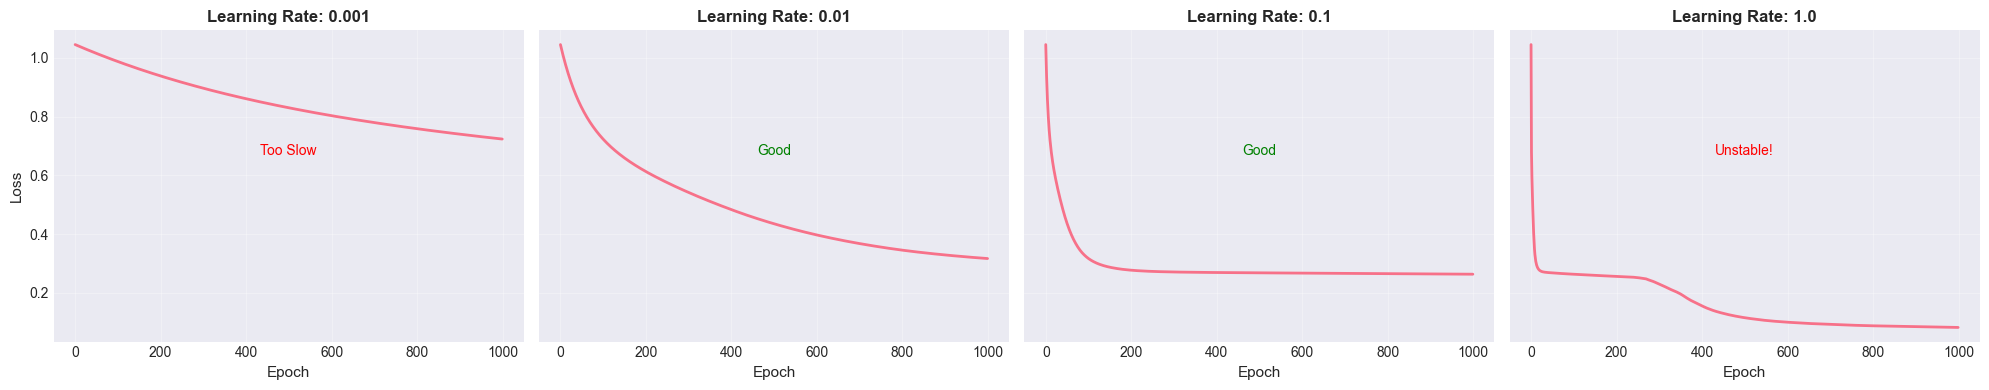


🎯 Learning Rate Selection:
  • Too small (0.001): Convergence is very slow and may get stuck.
  • Just right (0.01-0.1): Stable and efficient convergence.
  • Too large (1.0): Loss explodes or oscillates wildly; the model diverges.

  💡 A good starting point is often 0.01. Monitor the loss curve to tune it.


In [9]:
# Demonstration of different training scenarios
def compare_learning_rates():
    """Compare different learning rates"""
    
    # Generate simple dataset
    np.random.seed(42)
    X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
    X = X.T
    y = y.reshape(1, -1)
    
    learning_rates = [0.001, 0.01, 0.1, 1.0]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    
    for idx, lr in enumerate(learning_rates):
        ax = axes[idx]
        nn = NeuralNetwork(layer_dims=[2, 8, 1], activation='relu', learning_rate=lr, random_seed=42)
        nn.train(X, y, epochs=1000, verbose=False)
        
        ax.plot(nn.loss_history, linewidth=2)
        ax.set_title(f'Learning Rate: {lr}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=11)
        if idx == 0: ax.set_ylabel('Loss', fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Add interpretation text
        if lr == 0.001: ax.text(0.5, 0.6, 'Too Slow', transform=ax.transAxes, ha='center', color='red')
        elif lr == 1.0: ax.text(0.5, 0.6, 'Unstable!', transform=ax.transAxes, ha='center', color='red')
        else: ax.text(0.5, 0.6, 'Good', transform=ax.transAxes, ha='center', color='green')
            
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 Learning Rate Selection:")
    print("  • Too small (0.001): Convergence is very slow and may get stuck.")
    print("  • Just right (0.01-0.1): Stable and efficient convergence.")
    print("  • Too large (1.0): Loss explodes or oscillates wildly; the model diverges.")
    print("\n  💡 A good starting point is often 0.01. Monitor the loss curve to tune it.")

compare_learning_rates()

✅ Neural Network Created!
   Architecture: 2 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.05
   Total parameters: 3
✅ Neural Network Created!
   Architecture: 2 → 4 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.05
   Total parameters: 17
✅ Neural Network Created!
   Architecture: 2 → 8 → 4 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.05
   Total parameters: 65
✅ Neural Network Created!
   Architecture: 2 → 32 → 16 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.05
   Total parameters: 641


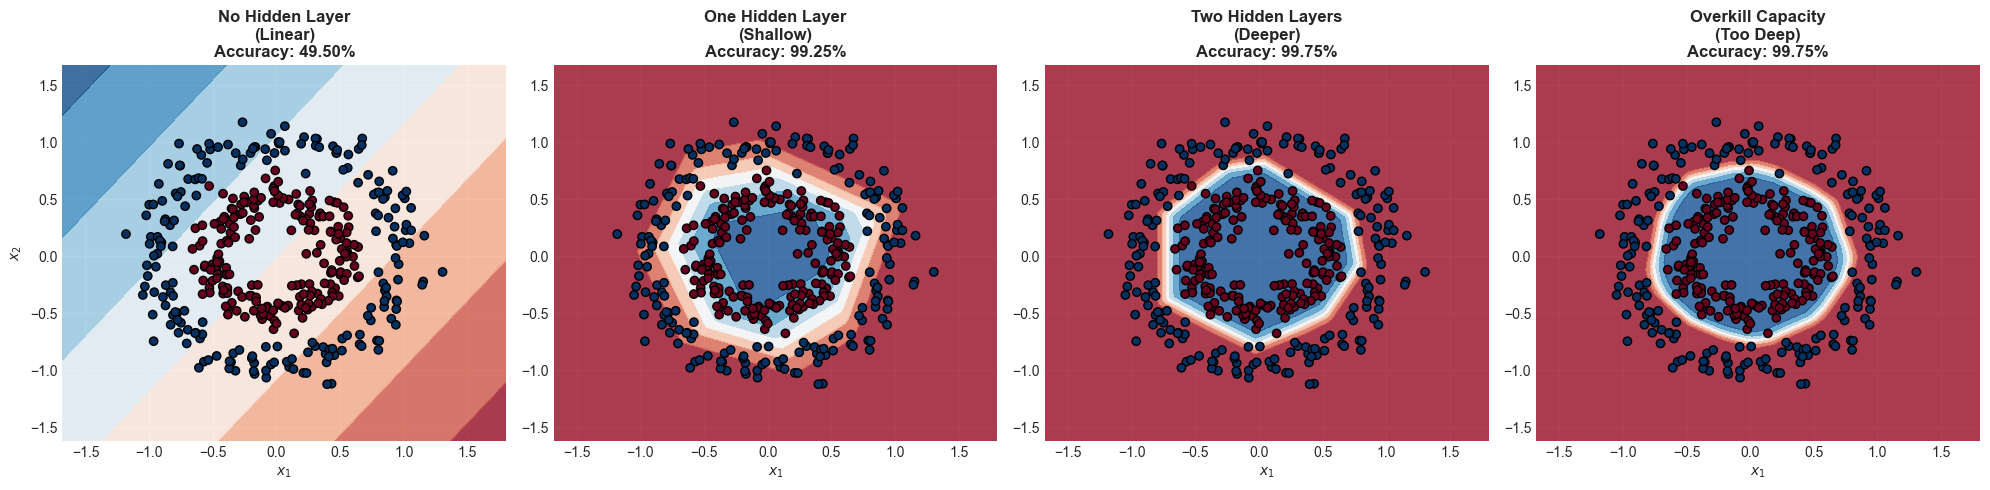


🏗️ Architecture Insights:
  • No hidden layers: Can only learn a linear boundary, fails on non-linear data.
  • One hidden layer: Can learn non-linear boundaries. Often sufficient for simple problems.
  • Deeper networks: Can learn more complex and intricate decision boundaries.
  • Too deep/wide: Risks overfitting the training data and may not generalize well.


In [10]:
# Visualizing the effect of network depth
def compare_network_architectures():
    """Compare different network architectures"""
    
    # Generate complex dataset
    np.random.seed(42)
    X, y = make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=42)
    X = X.T
    y = y.reshape(1, -1)
    
    architectures = [
        ([2, 1], 'No Hidden Layer\n(Linear)'),
        ([2, 4, 1], 'One Hidden Layer\n(Shallow)'),
        ([2, 8, 4, 1], 'Two Hidden Layers\n(Deeper)'),
        ([2, 32, 16, 1], 'Overkill Capacity\n(Too Deep)')
    ]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for idx, (arch, name) in enumerate(architectures):
        ax = axes[idx]
        nn = NeuralNetwork(layer_dims=arch, activation='relu', learning_rate=0.05, random_seed=42)
        nn.train(X, y, epochs=2000, verbose=False)
        
        # Create mesh for decision boundary
        x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
        y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        X_mesh = np.c_[xx.ravel(), yy.ravel()].T
        Z = nn.predict_proba(X_mesh).reshape(xx.shape)
        
        # Plot decision boundary and data points
        ax.contourf(xx, yy, Z, cmap='RdBu', alpha=0.8)
        ax.scatter(X[0, :], X[1, :], c=y.ravel(), cmap='RdBu_r', edgecolors='k')
        
        accuracy = nn.accuracy(X, y)
        ax.set_title(f'{name}\nAccuracy: {accuracy:.2%}', fontsize=12, fontweight='bold')
        ax.set_xlabel('$x_1$')
        if idx == 0: ax.set_ylabel('$x_2$')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🏗️ Architecture Insights:")
    print("  • No hidden layers: Can only learn a linear boundary, fails on non-linear data.")
    print("  • One hidden layer: Can learn non-linear boundaries. Often sufficient for simple problems.")
    print("  • Deeper networks: Can learn more complex and intricate decision boundaries.")
    print("  • Too deep/wide: Risks overfitting the training data and may not generalize well.")

compare_network_architectures()

<a id='example'></a>
## 10. Real-World Example: Complete Classification Pipeline

Let's apply everything we've learned to a complete classification problem. We will follow a standard machine learning pipeline from start to finish.

### The Pipeline
1. **Data Generation & Exploration**: Create and understand our dataset.
2. **Train-Validation-Test Split**: Properly partition data to evaluate generalization.
3. **Feature Scaling**: Standardize features to help the network learn efficiently.
4. **Model Architecture Design**: Choose the number of layers and neurons.
5. **Training**: Run the optimization process with a validation set.
6. **Evaluation & Visualization**: Analyze the results on the unseen test set.

In [11]:
# Complete classification pipeline
print("="*80)
print(" "*20 + "COMPLETE CLASSIFICATION PIPELINE")
print("="*80)

# Step 1: Data Generation
print("\n📊 Step 1: Generating Dataset")
X_raw, y_raw = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, 
                                 n_clusters_per_class=2, flip_y=0.1, random_state=42)
print(f"  • Dataset shape: {X_raw.shape}, Labels shape: {y_raw.shape}")

# Step 2: Train-Validation-Test Split
print("\n🔀 Step 2: Train-Validation-Test Split")
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)
print(f"  • Training: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]} samples")

# Step 3: Feature Scaling
print("\n📏 Step 3: Feature Scaling (Standardization)")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("  ✓ Features standardized (mean≈0, std≈1)")

# Transpose for our network format (features × samples)
X_train_final, y_train_final = X_train_scaled.T, y_train.reshape(1, -1)
X_val_final, y_val_final = X_val_scaled.T, y_val.reshape(1, -1)
X_test_final, y_test_final = X_test_scaled.T, y_test.reshape(1, -1)
print(f"  • Final training shape for NN: {X_train_final.shape}")

# Step 4: Model Architecture Design & Creation
print("\n🏗️ Step 4: Designing and Creating the Neural Network")
architecture = [X_train_final.shape[0], 20, 10, 1]  # Input -> Hidden(20) -> Hidden(10) -> Output
model = NeuralNetwork(
    layer_dims=architecture,
    activation='relu',
    learning_rate=0.01,
    lambda_reg=0.01,  # L2 regularization
    initialization='he',
    random_seed=42
)

# Step 5: Training the Model
print("\n🚀 Step 5: Training the Neural Network")
model.train(
    X_train_final, y_train_final,
    X_val_final, y_val_final,
    epochs=500,
    batch_size=64,
    verbose=True,
    print_every=100
)

# Step 6: Final Evaluation on Test Set
print("\n🏆 Step 6: Final Model Evaluation on Unseen Test Data")
test_acc = model.accuracy(X_test_final, y_test_final)
print(f"  • Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

overfitting_gap = model.train_acc_history[-1] - test_acc
status = "Good" if overfitting_gap < 0.1 else "Possible Overfitting"
print(f"  • Train-Test Accuracy Gap: {overfitting_gap:.4f} ({status})")

print("\n" + "="*80)
print(" "*25 + "PIPELINE COMPLETE! ✅")
print("="*80)

                    COMPLETE CLASSIFICATION PIPELINE

📊 Step 1: Generating Dataset
  • Dataset shape: (1000, 10), Labels shape: (1000,)

🔀 Step 2: Train-Validation-Test Split
  • Training: 640, Validation: 160, Test: 200 samples

📏 Step 3: Feature Scaling (Standardization)
  ✓ Features standardized (mean≈0, std≈1)
  • Final training shape for NN: (10, 640)

🏗️ Step 4: Designing and Creating the Neural Network
✅ Neural Network Created!
   Architecture: 10 → 20 → 10 → 1
   Activation: relu, Output: sigmoid
   Loss: bce, Learning Rate: 0.01
   Total parameters: 441

🚀 Step 5: Training the Neural Network

🚀 Starting Training...

Epoch    0/500 | Loss: 0.880977 | Train Acc: 0.5094 | Val Acc: 0.4875
Epoch  100/500 | Loss: 0.325968 | Train Acc: 0.8797 | Val Acc: 0.8250
Epoch  200/500 | Loss: 0.287619 | Train Acc: 0.8969 | Val Acc: 0.8375
Epoch  300/500 | Loss: 0.267912 | Train Acc: 0.9047 | Val Acc: 0.8438
Epoch  400/500 | Loss: 0.253140 | Train Acc: 0.9078 | Val Acc: 0.8500
Epoch  499/500 | 

<a id='visualization'></a>
## 11. Visualization & Analysis

After training, it's crucial to visualize the results to gain deeper insights into the model's behavior.

We will look at:
- **Learning Curves**: How did loss and accuracy evolve during training? This helps diagnose issues like slow learning or overfitting.
- **Prediction Distribution**: How confident is our model? Are the predictions clustered around 0 and 1, or are they uncertain (around 0.5)?
- **Confusion Matrix**: What kind of errors is the model making? (e.g., False Positives vs. False Negatives).
- **Weight Analysis**: What have the neurons learned? Visualizing weights can sometimes reveal patterns.

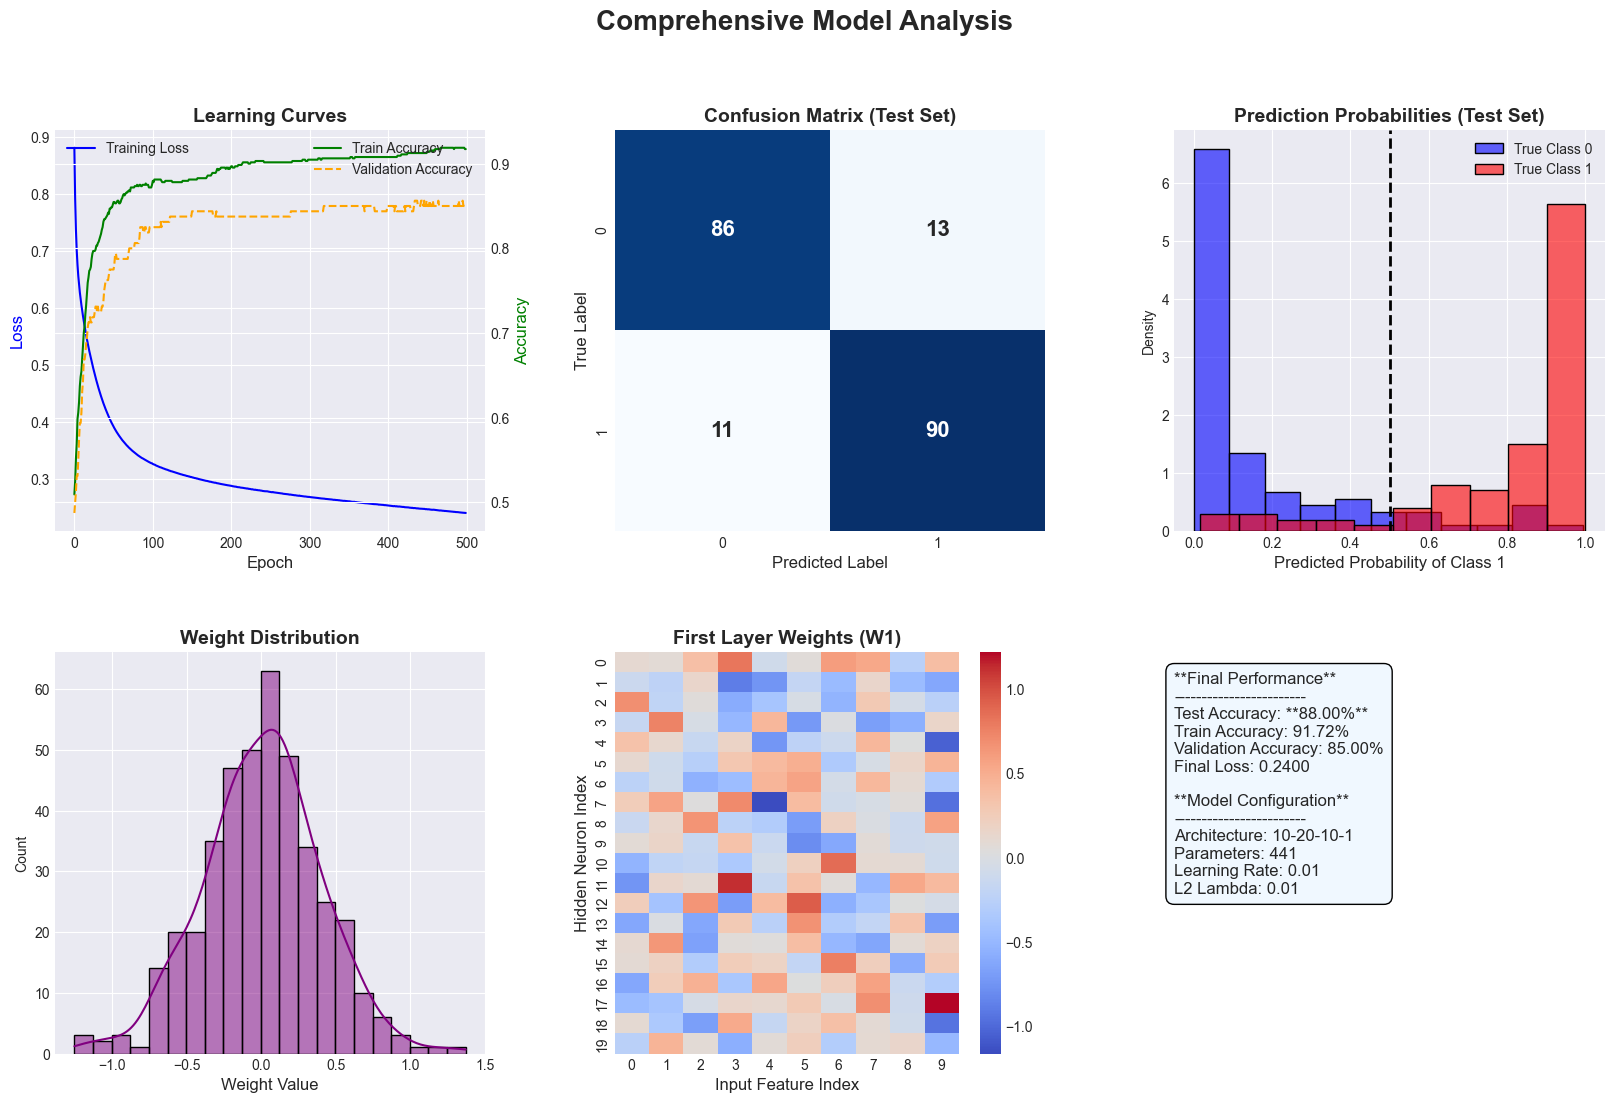

In [12]:
# Comprehensive visualization of results
from sklearn.metrics import confusion_matrix

def visualize_training_results(model, X_test, y_test):
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    fig.suptitle('Comprehensive Model Analysis', fontsize=20, fontweight='bold')
    
    # 1. Loss & Accuracy Curves
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = ax1.twinx() # twin axis for accuracy
    epochs = range(len(model.loss_history))
    ax1.plot(epochs, model.loss_history, 'b-', label='Training Loss')
    ax2.plot(epochs, model.train_acc_history, 'g-', label='Train Accuracy')
    ax2.plot(epochs, model.val_acc_history, 'orange', linestyle='--', label='Validation Accuracy')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12, color='blue')
    ax2.set_ylabel('Accuracy', fontsize=12, color='green')
    ax1.set_title('Learning Curves', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    ax1.grid(True)
    
    # 2. Confusion Matrix (Test Set)
    ax3 = fig.add_subplot(gs[0, 1])
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test.flatten(), y_pred_test.flatten())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False, 
                annot_kws={'size': 16, 'weight': 'bold'})
    ax3.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Predicted Label', fontsize=12)
    ax3.set_ylabel('True Label', fontsize=12)
    
    # 3. Prediction Probability Distribution
    ax4 = fig.add_subplot(gs[0, 2])
    test_probs = model.predict_proba(X_test).flatten()
    sns.histplot(test_probs[y_test.flatten()==0], color='blue', label='True Class 0', ax=ax4, alpha=0.6, stat='density')
    sns.histplot(test_probs[y_test.flatten()==1], color='red', label='True Class 1', ax=ax4, alpha=0.6, stat='density')
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=2)
    ax4.set_title('Prediction Probabilities (Test Set)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Predicted Probability of Class 1', fontsize=12)
    ax4.legend()
    
    # 4. Weight Distribution (All Layers)
    ax5 = fig.add_subplot(gs[1, 0])
    all_weights = np.concatenate([model.parameters[f'W{l}'].flatten() for l in range(1, model.n_layers + 1)])
    sns.histplot(all_weights, color='purple', ax=ax5, kde=True)
    ax5.set_title('Weight Distribution', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Weight Value', fontsize=12)
    
    # 5. First Layer Weights Visualization
    ax6 = fig.add_subplot(gs[1, 1])
    W1 = model.parameters['W1']
    sns.heatmap(W1, cmap='coolwarm', ax=ax6, cbar=True)
    ax6.set_title('First Layer Weights (W1)', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Input Feature Index', fontsize=12)
    ax6.set_ylabel('Hidden Neuron Index', fontsize=12)

    # 6. Performance Summary
    ax7 = fig.add_subplot(gs[1, 2])
    ax7.axis('off')
    summary_text = (
        f"**Final Performance**\n" +
        f"------------------------\n" +
        f"Test Accuracy: **{model.accuracy(X_test, y_test):.2%}**\n" +
        f"Train Accuracy: {model.train_acc_history[-1]:.2%}\n" +
        f"Validation Accuracy: {model.val_acc_history[-1]:.2%}\n" +
        f"Final Loss: {model.loss_history[-1]:.4f}\n\n" +
        f"**Model Configuration**\n" +
        f"------------------------\n" +
        f"Architecture: {'-'.join(map(str, model.layer_dims))}\n" +
        f"Parameters: {model._count_parameters():,}\n" +
        f"Learning Rate: {model.learning_rate}\n" +
        f"L2 Lambda: {model.lambda_reg}"
    )
    ax7.text(0.0, 0.95, summary_text, ha='left', va='top', fontsize=12,
             bbox=dict(boxstyle='round,pad=0.5', fc='aliceblue', ec='black'))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

visualize_training_results(model, X_test_final, y_test_final)

<a id='advanced'></a>
## 12. Advanced Topics & Extensions

Congratulations! You've built a complete neural network from scratch, understanding every component from the neuron to the training pipeline. This strong foundation is key to mastering deep learning.

### Where to Go From Here?

The world of deep learning is vast. Here are some exciting topics to explore next, which build directly on what you've learned:

1.  **Advanced Optimizers**:
    -   **Momentum**: Helps accelerate SGD in the relevant direction and dampens oscillations.
    -   **Adam**: An adaptive learning rate optimization algorithm that's become a default for many problems.

2.  **More Regularization Techniques**:
    -   **Dropout**: Randomly deactivates neurons during training to prevent co-adaptation and reduce overfitting.
    -   **Early Stopping**: Stop training when performance on a validation set stops improving.

3.  **Different Network Architectures**:
    -   **Convolutional Neural Networks (CNNs)**: The state-of-the-art for image recognition, using specialized layers (convolution, pooling) to learn spatial hierarchies.
    -   **Recurrent Neural Networks (RNNs)**: Designed for sequential data like text or time series, with loops that allow information to persist.

4.  **Deep Learning Frameworks**:
    -   Now that you understand the internals, using frameworks like **TensorFlow** or **PyTorch** will be much more intuitive. These tools automate the backward pass (auto-differentiation) and provide pre-built, highly optimized layers, allowing you to build massive networks efficiently.

### Final Thought

The journey from a single neuron to a fully trained network is a powerful one. By building it yourself, you've gained an intuition that can't be learned from just using libraries. Keep experimenting, keep learning, and happy coding!